In [3]:
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")
import scipy
from shapely.geometry import LineString, Point
from scipy import ndimage
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from matplotlib.pyplot import *
from spectral import *
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from mpl_toolkits.axes_grid1 import make_axes_locatable

def load_plt_setting():
    plt.style.use('seaborn-v0_8-white')
    mpl.rcParams['font.sans-serif'] = "Arial"
    mpl.rcParams['font.family'] = "sans-serif"
    mpl.rcParams['axes.linewidth'] = 2
    font = {'size': 32}
    mpl.rc('font', **font)
    mpl.rcParams['xtick.major.pad']='8'
    mpl.rcParams['ytick.major.pad']='8'
    plt.rcParams["font.weight"] = "normal"
    plt.rcParams["axes.labelweight"] = "normal"
    plt.rcParams['svg.fonttype'] = 'none'
    mpl.rcParams['axes.linewidth'] = 2

In [60]:
import cv2
from scipy import ndimage
from spectral import *

def segmentation(bil, hdr, rotate_crop_params, savepath, lower_pixel_thresh=50, upper_pixel_thresh=150000, band= 20, return_segment = False):
    '''
    =======================================
    == VISION SEGMENTATION OF HYPERCUBE  ==
    =======================================

    Inputs:
        bil:                  Path to the .bil hyperspectral datacube file
        hdr:                  Path to the .hdr hyperspectral datacube file
        rotate_crop_params:   User-defined dictionary of values used to rotate and crop the image. E.g., {'theta': -0.5, 'x1': 45, 'x2': 830, 'y1': 120, 'y2': 550}
        lower_pixel_thresh:   Elements containing fewer than the specified number of pixels will be removed
        upper_pixel_thresh:   Elements containing more than the specified number of pixels will be removed

    Outputs:
        data:                 An array containing the reflectance data extracted from the vision-segmented hyperspectral datacube
    '''

    # load spectral hypercube
    hypercube = envi.open(hdr, bil).load()  # load datacude
    singleband = hypercube[:, :, band]  # grab a single band to use for segmentation
    imshow(singleband)
    plt.title('Single Band')
    plt.show()
    singleband = (singleband / singleband.max() * 255).astype("uint8")
    # plot raw image
    imshow(hypercube, bands=(154, 78, 27))  # R: 154, G: 78, B: 27
    plt.title('Raw Image')
    plt.show()
    # crop/rotate single band
    singleband = ndimage.rotate(singleband, rotate_crop_params['theta'])  # reads image and rotates
    singleband = singleband[rotate_crop_params['y1']:rotate_crop_params['y2'],
                 rotate_crop_params['x1']:rotate_crop_params['x2']]  # crops image
    # crop/rotate hypercube
    hypercube = ndimage.rotate(hypercube, rotate_crop_params['theta'])  # reads image and rotates
    hypercube = hypercube[rotate_crop_params['y1']:rotate_crop_params['y2'],
                rotate_crop_params['x1']:rotate_crop_params['x2']]  # crops image
    # plot cropped image
    imshow(hypercube, bands=(154, 78, 27))  # R: 154, G: 78, B: 27
    plt.title('Cropped Image')
    plt.savefig(savepath+'/raw_image.png', dpi=300, bbox_inches='tight')
    plt.show()
    # transpose to segment along print direction
    singlebandT = ndimage.rotate(singleband, -90)
    hypercubeT = ndimage.rotate(hypercube, -90)
    # segment image with watershed
    watershed, edges = watershed_segment(singlebandT, small_elements_pixels=lower_pixel_thresh,
                                         large_elements_pixels=upper_pixel_thresh)
    # plot segmented image
    fig, ax = plt.subplots()
    ax.imshow(watershed.T, cmap='viridis')
    ax.invert_yaxis()
    plt.title('Segmented Image')
    plt.savefig(savepath+'/segmented_image.png', dpi=300, bbox_inches='tight')
    plt.show()
    # extract spectra from segmentation and format data
    idx_min = np.unique(watershed)[1:].min()
    idx_max = np.unique(watershed)[1:].max()
    idx_norms = []
    num_drop = len(np.unique(watershed)[1:])
    centroid_records = []
    idx_ = 1
    for drop in np.unique(watershed)[1:]:  # iterate through all segmented droplets, excluding background=0
        coords = np.argwhere(watershed == drop)
        centroid_x = coords[:, 0].mean()
        centroid_y = coords[:, 1].mean()
        spectra_all_pixels = []
        pixel_X_coord = []
        pixel_Y_coord = []
        for coord in coords:
            pixel_spectrum = hypercubeT[coord[0], coord[1], :]
            spectra_all_pixels.append(pixel_spectrum)
            pixel_X_coord.append(coord[0])
            pixel_Y_coord.append(coord[1])
        idx_norm = (drop - idx_min) / (idx_max - idx_min)
        idx_norms.append(idx_norm)
        data = pd.DataFrame(np.concatenate(
            (np.array(pd.read_csv('/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2023–2026 First Solar/03 Inorganic_Discovery/03_Data/bandgap bowing/HS camera/wavelength.txt', sep='\t', header=None)[0]).reshape(1, -1), np.array(spectra_all_pixels))).T)
        data = data.rename(columns={0: 'wavelength'})
        pixel_coords = pd.DataFrame({'X_coord': pixel_X_coord,'Y_coord': pixel_Y_coord})
        idx = idx_ -1
        idx_ = idx_+1
        centroid_records.append({
        'idx': idx,
        'drop_label': drop,
        'centroid_X': centroid_x,
        'centroid_Y': centroid_y
        })
        print(data)
        data.to_csv(f'{savepath}/pixel_reflectance_{idx}.csv')
        pixel_coords.to_csv(f'{savepath}/pixel_coordinates_{idx}.csv')
        centroid_df = pd.DataFrame(centroid_records)
        # centroid_df.to_csv(f'{savepath}/droplet_centroids.csv', index=False)

        tauc = data.iloc[:, 1:]
        wl = data.iloc[:, 0]

        # plot 
        # fig, ax = plt.subplots(figsize=(8, 4))
        # colormap = mpl.cm.get_cmap('viridis')
        # for i in range(tauc.shape[1]):
        #     rgba = colormap(1-idx_norm)
        #     ax.plot(wl,tauc.iloc[:,i] / np.max(tauc.iloc[:,i]),c=rgba)  # Normalize each spectrum for visualization
        
        # ax.grid(which='minor', color='gray',linestyle='--', alpha=0.35)
        # ax.grid(which='major', color='gray',linestyle='--', alpha=0.35)
        # ax.set_yticklabels([])
        # plt.xlabel(r'Wavelength, $\lambda$ (nm)')
        # plt.ylabel(r'Reflectance, $R$ (a.u.)')
        # fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=100), cmap=mpl.cm.viridis), ax=ax)
        # plt.title('Extracted Reflectance Spectra')
        # plt.savefig(f'{savepath}/pixel_reflectance_{idx}.png', dpi=300, bbox_inches='tight', transparent=True)
        # plt.show()
    
    if return_segment:
        return data, watershed.T,num_drop
    else:
        return data


# Sub-functions for segmentation()

def segment_on_dt(a, img, threshold):
    '''
    Implements watershed segmentation.

    Inputs:
        a:         Image input
        img:       Threshold binned image
        threshold: RGB threshold value

    Outputs:
        lbl:       Borders of segmented droplets
        wat:       Segmented droplets via watershed
        lab:       Indices of each segmented droplet
    '''
    # estimate the borders of droplets based on known and unknown background + foreground (computed using dilated and erode)
    kernel = np.ones((4, 4), np.uint8)  #default parameter: kernel = np.ones((2, 2), np.uint8)
    border = cv2.dilate(img, None, iterations=1)
#     border = cv2.erode(border, kernel)
    border = border - cv2.erode(border, kernel)
    # segment droplets via distance mapping and thresholding
    dt = cv2.distanceTransform(img, 2, 3)
    dt = ((dt - dt.min()) / (dt.max() - dt.min()) * 255).astype(np.uint8)
    _, dt = cv2.threshold(dt, threshold, 255, cv2.THRESH_BINARY)
    # dt = 255 - dt     ##adjust based on if using contrast enhancing
    # obtain the map of segmented droplets with corresponding indices
    lbl, ncc = ndimage.label(dt)
    lbl = lbl * (255 / (ncc + 1))
    lab = lbl 
    # Completing the markers now.
    lbl[border == 255] = 255
    lbl = lbl.astype(np.int32)
    a = cv2.cvtColor(a,cv2.COLOR_GRAY2BGR)  # we must convert grayscale to BGR because watershed only accepts 3-channel inputs
    wat = cv2.watershed(a, lbl)
    lbl[lbl == -1] = 0
    lbl = lbl.astype(np.uint8)
    return 255 - lbl, wat, lab  # return lab, the segmented and indexed droplets

def watershed_segment(image, small_elements_pixels=0, large_elements_pixels=999999):
    '''
    Applies watershed image segmentation to separate droplet pixels from background pixels.

    Inputs:
        image:                   Input droplet image to segment
        small_elements_pixels:   Removes small elements that contain fewer than the specified number of pixels.
        large_elements_pixels:   Removes large elements that contain more than the specified number of pixels.

    Outputs:
        water:                   Watershed segmented droplets
        labs:                    Edges to each watershed segmented droplet
    '''
    RGB_threshold = 0
    img = image.copy()
    img = 255 - img
    
    img_bin = cv2.GaussianBlur(img,(5,5),0) 
    _, img_bin = cv2.threshold(img_bin, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, img_bin = cv2.threshold(img, 0, 255, cv2.THRESH_OTSU)
                               # threshold image using Otsu's binarization # https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html
    #img_bin = cv2.morphologyEx(img, cv2.MORPH_CLOSE, np.ones((8, 8), dtype=int))
    img_bin = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, np.ones((1, 1), np.uint8))
    img_bin = cv2.erode(img_bin, np.ones((2, 2), np.uint8))

    result, water, labs = segment_on_dt(a=img, img=img_bin,
                                        threshold=RGB_threshold)  # segment droplets from background and return indexed droplets
    water = cv2.dilate(water.astype('uint8'), np.ones((4, 4), np.uint8))
    water = cv2.medianBlur(water,5) 
    # remove small/large elements
    uniq_full, uniq_counts = np.unique(water,
                                       return_counts=True)  # get all unique watershed indices with pixel counts
    large_elements = uniq_full[uniq_counts > large_elements_pixels]  # mask large elements based on number of pixels
    small_elements = uniq_full[uniq_counts < small_elements_pixels] # mask small elements based on number of pixels
    for n in range(len(large_elements)):
        water[water == large_elements[n]] = 0  # remove all large elements
    for n in range(len(small_elements)):
        water[water == small_elements[n]] = 0  # remove all small elements
    return water, labs

Computing Experiment Br100_s0_hr0. . .


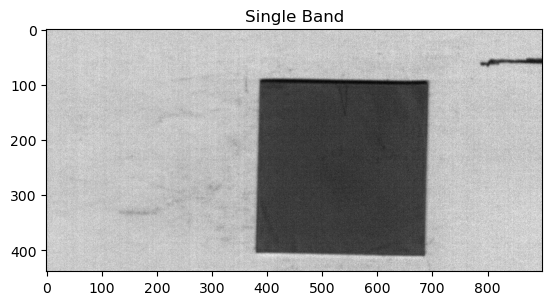

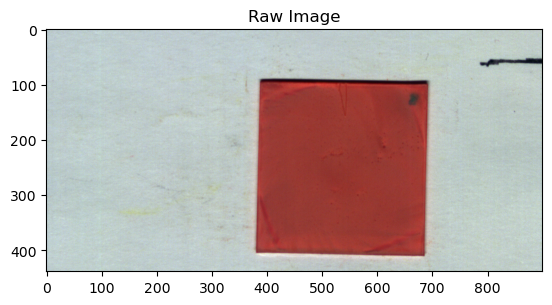

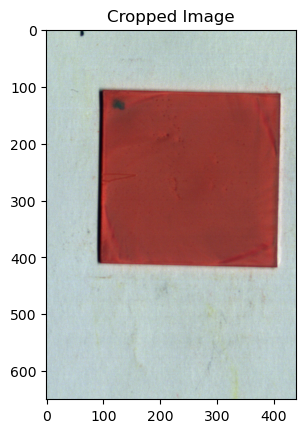

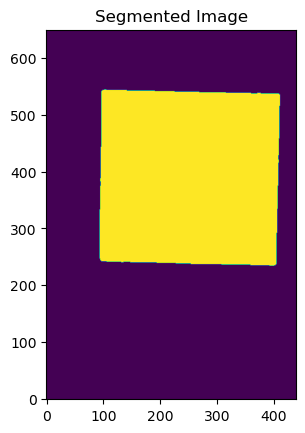

     wavelength       1       2       3       4       5       6       7  \
0        381.51  0.5982  0.5222  0.5702  0.6586  0.4087  0.4173  0.8695   
1        383.52  0.6539  0.7918  0.6367  0.5696  0.4007  0.6398  0.4843   
2        385.52  0.6390  0.7289  0.6436  0.8803  0.3098  0.6641  0.7462   
3        387.53  0.5582  0.4874  0.8415  0.5186  0.4800  0.1999  0.4076   
4        389.54  0.8105  0.4931  0.6401  0.6514  0.5945  0.7864  0.6744   
..          ...     ...     ...     ...     ...     ...     ...     ...   
295     1010.14  0.5218  0.4782  0.4134  0.4605  0.4273  0.4573  0.4922   
296     1012.40  0.4837  0.5085  0.5118  0.4084  0.3993  0.4875  0.4569   
297     1014.66  0.4490  0.4177  0.4048  0.3923  0.5444  0.4029  0.3506   
298     1016.92  0.4580  0.4607  0.4177  0.4493  0.4910  0.5524  0.4332   
299     1019.18  0.5017  0.3791  0.5210  0.4636  0.4186  0.4403  0.4481   

          8       9  ...   94274   94275   94276   94277   94278   94279  \
0    0.4382  0.2820  ..

In [72]:
datapath = f'/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2024-2026 TRI/04_Data/Code/phase_purity_testset/data_for_fang'
savepath = f'/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2024-2026 TRI/04_Data/Code/phase_purity_testset/data_for_fang'
experiments = [
    'Br100_s0_hr0'
]
for experiment in experiments:
    print(f'Computing Experiment {experiment}. . .')
    
    # read datacubes
    bil = f'{datapath}/{experiment}.bil'
    hdr = f'{datapath}/{experiment}.bil.hdr'
    rotate_crop_params = {'theta': 90, 'x1': 0, 'x2': 1100, 'y1': 100, 'y2': 750} # USER DEFINED ROTATE/CROP PARAMETERS
    data, sgmnt,num_drop = segmentation(bil=bil, hdr=hdr, rotate_crop_params=rotate_crop_params, savepath=savepath, return_segment = True)


In [42]:
def read_films(film_idx, datapath):
    reflectance = pd.read_csv(f'{datapath}pixel_reflectance_{film_idx}.csv', header=None)
    coords = pd.read_csv(f'{datapath}pixel_coordinates_{film_idx}.csv', header=None)

    # Remove header rows and extract data properly
    coords = coords.iloc[1:].apply(pd.to_numeric, errors='coerce')
    spectra = reflectance.iloc[1:, 2:].apply(pd.to_numeric, errors='coerce') # Skip wavelength column
    wavelength = reflectance.iloc[1:, 1].apply(pd.to_numeric, errors='coerce').values

    # Use pixel indices for exact correspondence
    valid_pixels = coords.dropna()
    pixel_ids = valid_pixels.iloc[:, 0].astype(int).values

    spectra_mat = spectra.iloc[:, pixel_ids].values
    # Drop wavelength rows with NaNs across selected pixels
    row_mask = ~np.isnan(spectra_mat).any(axis=1)
    spectra_mat = spectra_mat[row_mask, :]
    wavelength = wavelength[row_mask]

    spectra_array = spectra_mat

    df = pd.DataFrame({
        "pixel_id": pixel_ids,
        "x": valid_pixels.iloc[:, 1].values,
        "y": valid_pixels.iloc[:, 2].values,
        "spectrum": [spectra_array[:, i] for i in range(spectra_array.shape[1])]
    })
    
    # Convert reflectance to absorption coefficient and then to Tauc
    R = spectra_array / 10000  # Normalize reflectance (assuming values are scaled)
    
    # Kubelka-Munk transformation: F(R) = (1-R)²/(2R)
    k = (1. - R) ** 2  # k=(1-R)^2
    s = 2 * R  # s = 2*R
    F = k / s  # absorption coefficient F(R)
    
    # Convert wavelength to energy (eV)
    ev = 1240. / wavelength  # E(eV) = 1240/λ(nm)
    
    # Calculate Tauc: (αhν)² = (F(R) * hν)² for direct bandgap
    # We need to broadcast ev across all pixels
    ev_matrix = np.broadcast_to(ev.reshape(-1, 1), F.shape)
    
    # Tauc plot: (αhν)² vs hν for direct bandgap analysis
    tauc = (F * ev_matrix) ** 2 
    # Create the plot
    # fig, ax = plt.subplots(figsize=(10, 6))
    # colormap = mpl.cm.get_cmap('RdPu')

    # Plot each pixel spectrum with a different color
    # n_pixels = len(df)
    # for i in range(n_pixels):
    #     # Normalize color index to [0, 1] range
    #     color_idx = i / (n_pixels - 1) if n_pixels > 1 else 0
    #     rgba = colormap(color_idx)
    
    #     # Normalize each spectrum for visualization (optional)
    #     spectrum = spectra_array[:, i]
    #     if np.max(spectrum) > 0:  # Avoid division by zero
    #         normalized_spectrum = spectrum-np.min(spectrum) / (np.max(spectrum)-np.min(spectrum))
    #     else:
    #         normalized_spectrum = spectrum
    
    #     ax.plot(wavelength, normalized_spectrum, c=rgba, linestyle='-', alpha=0.3, linewidth=0.8)

    # # Styling
    # ax.grid(which='minor', color='gray', linestyle='--', alpha=0.35)
    # ax.grid(which='major', color='gray', linestyle='--', alpha=0.35)
    # ax.set_xlabel(r'Wavelength, $\lambda$ (nm)')
    # ax.set_ylabel(r'Reflectance, $R$ (a.u.)')
    # ax.set_xlim(400, 900)

    # # Add colorbar
    # sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=n_pixels-1), cmap=colormap)
    # sm.set_array([])
    # cbar = fig.colorbar(sm, ax=ax)
    # cbar.set_label('Pixel Index')

    # # plt.title(f'Film 0 - All Pixel Spectra (n={n_pixels})')
    # plt.tight_layout()
    # plt.savefig(f'{savepath}/film_{film_idx}_all_spectra.png', dpi=300)
    # plt.show()

    # Extract absorption edges for each pixel
    return df, spectra_array, wavelength, tauc, ev

In [58]:
def cal_bandgap(ev_min, ev_max, tauc, ev, noise_filter_percentile=5, threshold_percentile=10, min_consecutive_points=3, merge_gap_threshold=0.05, savepath=None, plot_pixels=None, film_idx=0):
    """
    Calculate bandgaps for all pixels using derivative-based analysis.
    
    Parameters:
    - plot_pixels: None (no plots), 'first_n' (plot first 3), 'all' (plot all), or list of pixel indices
    """
    # 1. Select wavelength range
    ev_mask = (ev >= ev_min) & (ev <= ev_max)
    ev_selected = ev[ev_mask]

    # Select energy range from Tauc plots
    tauc_selected = tauc[ev_mask, :]  
    tauc_df = pd.DataFrame(tauc_selected)
    ev_series = pd.Series(ev_selected, name='eV')
    tauc_combined = pd.concat([ev_series, tauc_df], axis=1)
    
    # 2. Apply Savitzky-Golay smoothing
    window_length = 21  # Adjust based on your data quality and noise level
    polyorder = 3       # Polynomial order for S-G filter
    tauc_smooth = scipy.signal.savgol_filter(tauc_combined.iloc[:, 1:], window_length=window_length, polyorder=polyorder, axis=0)
    
    # Calculate first derivative of smoothed data
    smooth_first_derivative = np.gradient(tauc_smooth, tauc_combined.iloc[:, 0], axis=0)

    # 3. Find derivative regions and fit for bandgaps
    bandgaps = []  # list of bandgaps for all spectra
    total_pixels = tauc_smooth.shape[1]
    
    print(f"Processing {total_pixels} pixels...")
    
    # Determine which pixels to plot
    if plot_pixels == 'first_n':
        pixels_to_plot = list(range(min(3, total_pixels)))
    elif plot_pixels == 'all':
        pixels_to_plot = list(range(total_pixels))
    elif isinstance(plot_pixels, (list, tuple)):
        pixels_to_plot = [p for p in plot_pixels if 0 <= p < total_pixels]
    else:
        pixels_to_plot = []
    
    for i in range(total_pixels):
            
        bandgaps_per_tauc = []
        
        # Get current pixel data
        TAUC_X = tauc_combined.iloc[:, 0].values  # Energy values
        TAUC_Y = tauc_smooth[:, i]  # Smoothed Tauc values for this pixel
        current_derivative = smooth_first_derivative[:, i]
        
        # Filter derivative to keep only positive values (positive slope regions)
        derivative_for_analysis = np.where(current_derivative > 0, current_derivative, 0)
    
        # Apply noise filtering
        if np.any(derivative_for_analysis > 0):
            noise_threshold = np.percentile(derivative_for_analysis[derivative_for_analysis > 0], noise_filter_percentile)
        else:
            noise_threshold = 0
            
        derivative_filtered = np.where(derivative_for_analysis > noise_threshold, derivative_for_analysis, 0)
        
        # Set threshold for significant derivative regions
        max_filtered = np.max(derivative_filtered)
        threshold = max_filtered * (threshold_percentile / 100.0)
        
        # Find points above threshold
        above_threshold = derivative_filtered > threshold
        total_above_threshold = np.sum(above_threshold)

        if total_above_threshold == 0:
            bandgaps_per_tauc.append(0.0)
        else:
            # Find continuous regions above threshold
            regions = []
            start_idx = None
    
            for j, is_above in enumerate(above_threshold):
                if is_above and start_idx is None:
                    start_idx = j
                elif not is_above and start_idx is not None:
                    region_length = j - start_idx
                    if region_length >= min_consecutive_points:
                        regions.append((start_idx, j-1, TAUC_X[start_idx], TAUC_X[j-1]))
                    start_idx = None
            
            # Handle case where region extends to end of array
            if start_idx is not None:
                region_length = len(above_threshold) - start_idx
                if region_length >= min_consecutive_points:
                    regions.append((start_idx, len(above_threshold)-1, 
                                  TAUC_X[start_idx], TAUC_X[len(above_threshold)-1]))
    
            if not regions:
                bandgaps_per_tauc.append(0.0)
            else:
                # Merge nearby regions based on energy gap between end of current and start of next
                if len(regions) > 1:
                    merged_regions = []
                    current_region = regions[0]

                    for j, next_region in enumerate(regions[1:], 1):
                        # Compare end energy of current region with start energy of next region
                        gap = next_region[2] - current_region[3]  # Gap in energy (eV)

                        if np.abs(gap) <= merge_gap_threshold:  # Use merge threshold
                            # Merge regions: combine start of current with end of next
                            current_region = (current_region[0], next_region[1], 
                                            current_region[2], next_region[3])
                        else:
                            # Keep regions separate
                            merged_regions.append(current_region)
                            current_region = next_region

                    merged_regions.append(current_region)
                    regions = merged_regions
                
                # Width filtering
                min_width_eV = 0.05
                filtered_regions = []
                for region in regions:
                    start_idx, end_idx, start_energy, end_energy = region
                    width = np.abs(end_energy - start_energy)
                    if width >= min_width_eV:
                        filtered_regions.append(region)

                regions = filtered_regions
                
                if len(regions) == 0:
                    bandgaps_per_tauc.append(0.0)
                else:
                    # Calculate baseline from lowest energy region
                    max_end_idx = np.max([region[1] for region in regions])
                    baseline_start = min(max_end_idx + 5, len(TAUC_Y) - 10)
                    baseline = np.median(TAUC_Y[baseline_start:])
                    
                    # Fit each region to find bandgaps
                    fit_lines = []
                    for k, (start_idx, end_idx, start_energy, end_energy) in enumerate(regions):
                        try:
                            X_region = TAUC_X[start_idx:end_idx+1]
                            Y_region = TAUC_Y[start_idx:end_idx+1]
                            
                            if len(X_region) < 3:  # Need at least 3 points for fitting
                                continue

                            if np.abs(TAUC_Y[start_idx]-TAUC_Y[end_idx+1])<baseline*8:
                                continue

                            if np.abs(TAUC_X[start_idx]-TAUC_X[end_idx+1])>0.3:
                                continue
                            # Adjust Y values relative to baseline
                            Y_adjusted = Y_region - baseline
                            
                            # Fit linear regression
                            model = LinearRegression().fit(X_region.reshape(-1, 1), Y_adjusted.reshape(-1, 1))
                            y_fit = model.predict(X_region.reshape(-1, 1)).flatten()
                            fit_lines.append((X_region, y_fit + baseline))  # Add baseline back for plotting
                            
                            # Calculate bandgap from x-intercept
                            slope = model.coef_[0][0]
                            intercept = model.intercept_[0]
                            
                            if abs(slope) > 1e-10:
                                Eg = -intercept / slope
                                
                                # Check reasonableness
                                if 1.0 <= Eg <= 3.0:
                                    # Check for duplicates
                                    is_unique = True
                                    for existing_bg in bandgaps_per_tauc:
                                        if abs(Eg - existing_bg) < 0.05:
                                            is_unique = False
                                            break
                                    
                                    if is_unique:
                                        bandgaps_per_tauc.append(Eg)
                                        
                        except Exception as e:
                            if i in pixels_to_plot:  # Only print errors for plotted pixels
                                print(f"      Error in fitting pixel {i}, region {k+1}: {e}")
                            continue
                
                # If no bandgaps found, add default
                if len(bandgaps_per_tauc) == 0:
                    bandgaps_per_tauc.append(0.0)

        # Plot if this pixel is in the visualization list
        if i in pixels_to_plot:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
            
            # Plot Tauc curve
            ax1.plot(TAUC_X, TAUC_Y, 'b-', lw=2, label='Tauc plot')
            if 'baseline' in locals():
                ax1.axhline(baseline, color='purple', linestyle=':', alpha=0.7, label=f'Baseline = {baseline:.2e}')
            if 'fit_lines' in locals() and fit_lines:
                for k, (x_fit, y_fit) in enumerate(fit_lines):
                    ax1.plot(x_fit, y_fit, '--', lw=2, color='orange',
                            label=f'Linear fit' if k == 0 else "")
            
            # Mark bandgaps
            for j, bg in enumerate(bandgaps_per_tauc):
                if bg > 0:
                    ax1.axvline(bg, color='red', linestyle='--', alpha=0.7, 
                               label=f'Bandgap: {bg:.3f} eV' if j == 0 else f'{bg:.3f} eV')
            
            ax1.set_xlabel('Energy (eV)')
            ax1.set_ylabel('(αhν)² (a.u.)')
            ax1.set_title(f'Pixel {i} - Tauc Analysis (Bandgaps: {[f"{bg:.3f}" for bg in bandgaps_per_tauc if bg > 0]})')
            ax1.grid(True, alpha=0.3)
            ax1.legend()
            
            # Plot derivative with regions
            ax2.plot(TAUC_X, current_derivative, 'g-', alpha=0.5, label='Raw derivative')
            ax2.plot(TAUC_X, derivative_filtered, 'r-', lw=2, label='Filtered derivative')
            ax2.axhline(threshold, color='orange', linestyle='--', label=f'Threshold ({threshold:.2e})')
            
            # Mark detected regions
            if 'regions' in locals() and regions:
                for k, (start_idx, end_idx, start_energy, end_energy) in enumerate(regions):
                    ax2.axvspan(start_energy, end_energy, alpha=0.3, color='yellow', 
                               label=f'Region {k+1}' if k == 0 else "")
            
            # Mark bandgaps
            for bg in bandgaps_per_tauc:
                if bg > 0:
                    ax2.axvline(bg, color='red', linestyle='--', alpha=0.7)
            
            ax2.set_xlabel('Energy (eV)')
            ax2.set_ylabel('d(αhν)²/dE (a.u.)')
            ax2.set_title(f'Derivative Analysis')
            ax2.grid(True, alpha=0.3)
            ax2.legend()
            
            plt.tight_layout()
            if savepath:
                plt.savefig(f'{savepath}/film_{film_idx}_pixel_{i}_analysis.png', dpi=300, bbox_inches='tight')
            plt.show()

        # Add the bandgaps from this pixel to the main bandgaps list
        bandgaps.append(bandgaps_per_tauc)
    print(f"Total pixels processed: {len(bandgaps)}")
    
    # Summary statistics
    valid_bandgaps = [bg for pixel_bgs in bandgaps for bg in pixel_bgs if bg > 0]
    if valid_bandgaps:
        print(f"Valid bandgaps found: {len(valid_bandgaps)}")
    
    return bandgaps

Processing 94137 pixels...


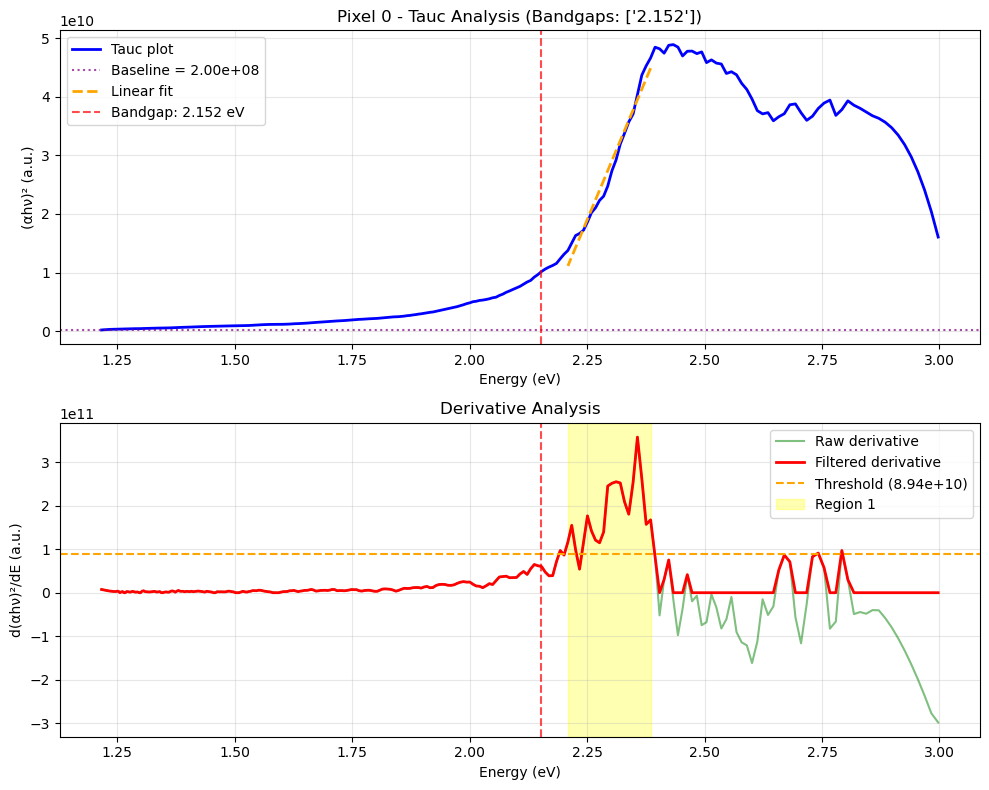

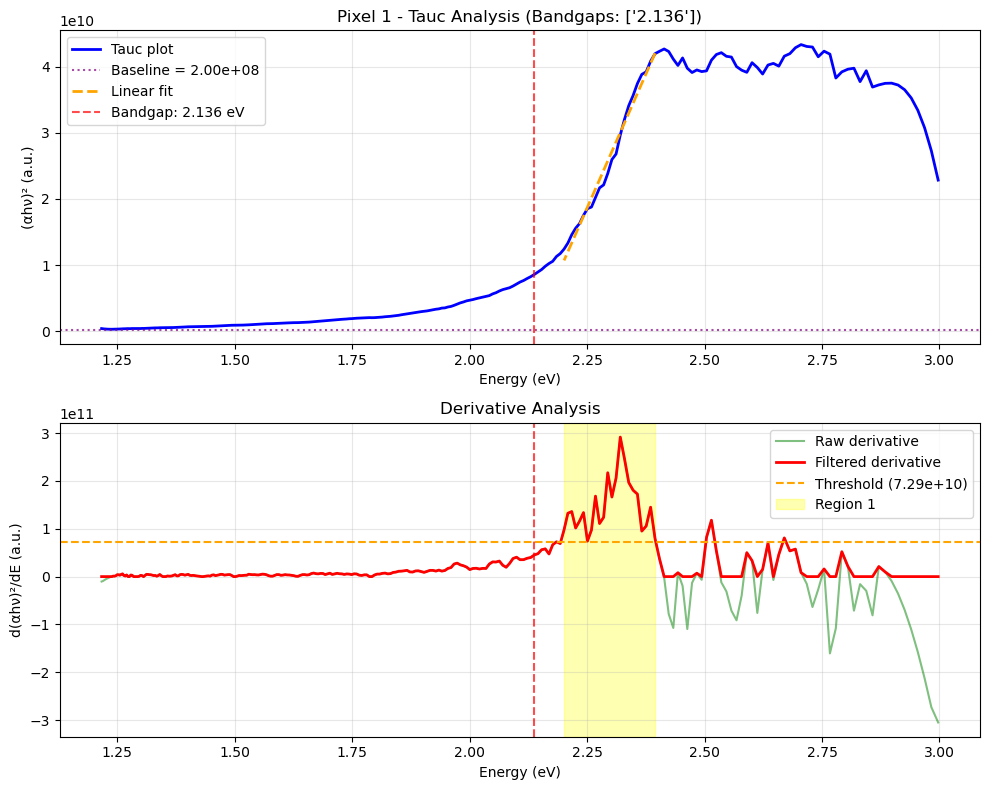

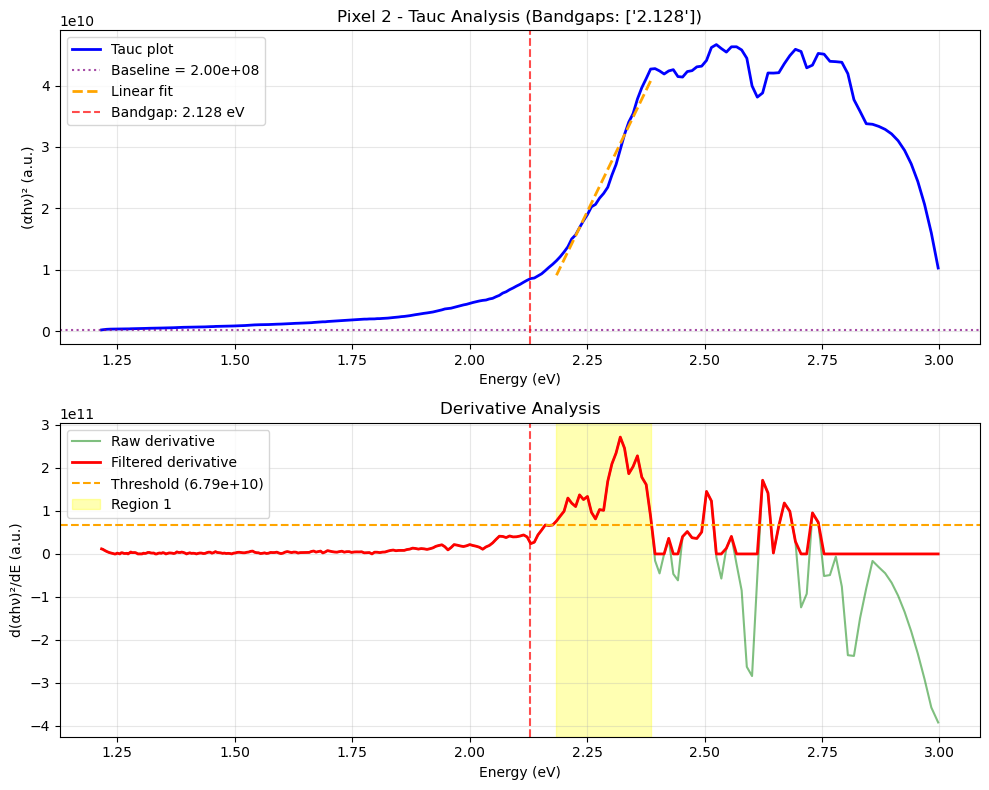

Total pixels processed: 94137
Valid bandgaps found: 97215


In [76]:
ev_min = 1.0  # Start from lower energy
ev_max = 3.0  

datapath = f'/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2024-2026 TRI/04_Data/Code/phase_purity_testset/data_for_fang/'
savepath = f'/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2024-2026 TRI/04_Data/Code/phase_purity_testset/data_for_fang/'
for film_idx in range(1,2):
    df, spectra_array, wavelength, tauc, ev = read_films(film_idx, datapath)

    bandgaps = cal_bandgap(ev_min, ev_max, tauc, ev, 
                        noise_filter_percentile=5,      # Filter out bottom 5% of positive derivatives as noise
                        threshold_percentile=25,        # Use top 25% of filtered derivatives as threshold
                        min_consecutive_points=3,       # Require at least 3 consecutive points for a region
                        merge_gap_threshold=0.05,       # Merge regions within 0.15 eV of each other
                        plot_pixels='first_n',
                        savepath=None)
    bandgaps_df = pd.DataFrame(bandgaps)
    bandgaps_df.to_csv(f'{savepath}/film_{film_idx}_bandgaps.csv', index=False)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


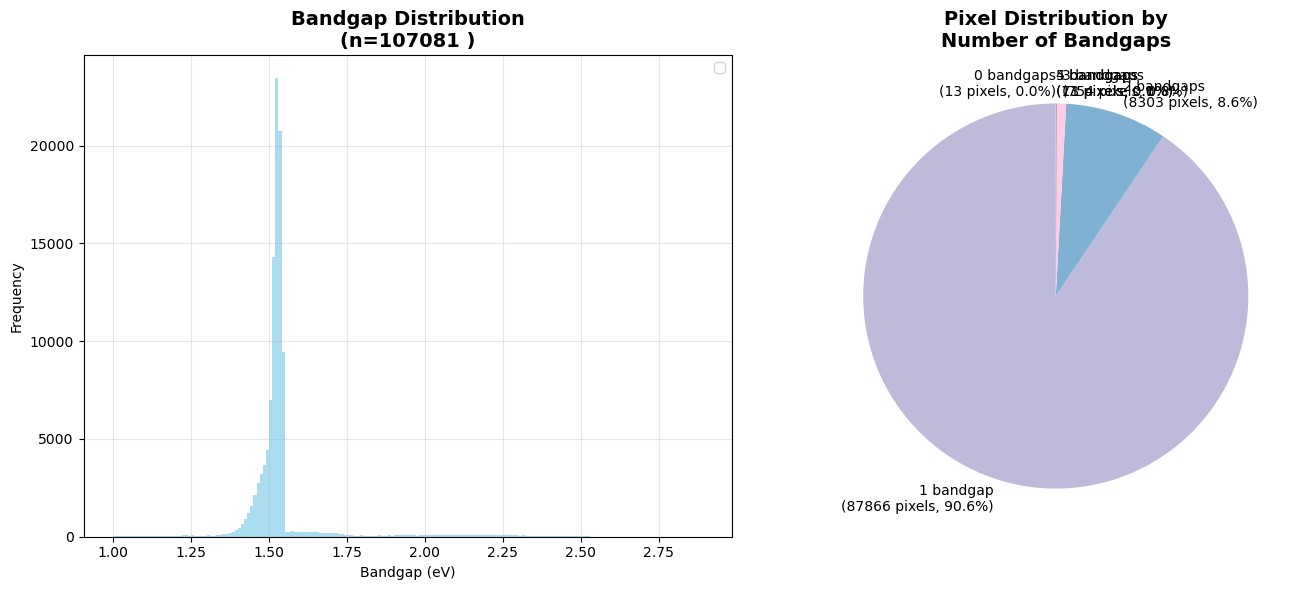

In [120]:
def bandgap_distribution(bandgaps, df=None, savepath=None):
    """
    Create two-panel bandgap distribution analysis:
    1. Histogram of all bandgap values
    2. Pie chart showing proportion of pixels by number of bandgaps
    """
    # Extract all valid bandgaps and count per pixel
    all_bandgaps = []
    num_bandgaps_per_pixel = []

    for i, pixel_bgs in enumerate(bandgaps):
        valid_bgs = [bg for bg in pixel_bgs if bg > 0]
        num_bandgaps_per_pixel.append(len(valid_bgs))

        # Store all valid bandgaps
        for bg in valid_bgs:
            all_bandgaps.append(bg)

    all_bandgaps = np.array(all_bandgaps)
    num_bandgaps_per_pixel = np.array(num_bandgaps_per_pixel)
    
    # Get counts for pie chart
    unique_counts, pixel_counts = np.unique(num_bandgaps_per_pixel, return_counts=True)
    total_pixels = len(bandgaps)
    
    # Create two-panel figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # 1. Histogram of ALL bandgap values
    if len(all_bandgaps) > 0:
        # Use bin width of 0.1 eV
        bin_range = np.max(all_bandgaps) - np.min(all_bandgaps)
        n_bins = max(int(bin_range / 0.01), 10)  # At least 10 bins
        
        counts, bins, patches = ax1.hist(all_bandgaps, bins=n_bins, alpha=0.7, color='skyblue')
        ax1.set_title(f'Bandgap Distribution\n(n={len(all_bandgaps)} )', 
                     fontsize=14, fontweight='bold')
        ax1.set_xlabel('Bandgap (eV)')
        ax1.set_ylabel('Frequency')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
    else:
        ax1.text(0.5, 0.5, 'No valid bandgaps found', ha='center', va='center', 
                transform=ax1.transAxes, fontsize=12)
        ax1.set_title('Bandgap Distribution')
        ax1.set_xlabel('Bandgap (eV)')
        ax1.set_ylabel('Frequency')
    
    # 2. Pie chart showing proportion of pixels by number of bandgaps
    labels = [f'{count} bandgap{"s" if count != 1 else ""}\n({pixel_count} pixels, {pixel_count/total_pixels*100:.1f}%)' 
              for count, pixel_count in zip(unique_counts, pixel_counts)]
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_counts)))
    
    wedges, texts, autotexts = ax2.pie(pixel_counts, labels=labels, colors=colors, 
                                      autopct='', startangle=90, textprops={'fontsize': 10})
    ax2.set_title('Pixel Distribution by\nNumber of Bandgaps', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    if savepath:
        plt.savefig(f'{savepath}/bandgap_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()


bandgap_distribution_results = bandgap_distribution(bandgaps, df, savepath=None)

In [74]:
def calculate_phase_purity_score(
    bandgaps,
    bad_phase_ranges,
    sigma_good=0.05,
    sigma_bad=0.08,
    penalty_lambda=1.0,
    exclusion_delta=0.1,
    ev_min=1.0,
    ev_max=4.0,
    x_grid=None,
    save_figures=True,
    return_debug=True
):
    """
    Compute phase purity score from pixel-level bandgap outputs.

    Parameters
    ----------
    bandgaps : list of lists
        Output from cal_bandgap(...), where each entry contains the detected
        bandgaps for one pixel.
    bad_phase_means : list[float]
        Known impurity phase bandgap means.
    sigma_good, sigma_bad, penalty_lambda, exclusion_delta : float
        Scoring hyperparameters.
    ev_min, ev_max : float
        Bandgap search range used to define the KDE grid.
    x_grid : np.ndarray or None
        Optional predefined energy grid. If None, create one internally.
    return_debug : bool
        Whether to return intermediate quantities for plotting/debugging.

    Returns
    -------
    dict
        Phase purity results.
    """
    import numpy as np
    from scipy.stats import norm, gaussian_kde
    from scipy import integrate
    from scipy.interpolate import interp1d

    # -------- collect valid bandgaps --------
    all_bandgaps = []
    num_bandgaps_per_pixel = []

    for pixel_bgs in bandgaps:
        valid_bgs = [bg for bg in pixel_bgs if bg > 0 and np.isfinite(bg)]
        num_bandgaps_per_pixel.append(len(valid_bgs))
        all_bandgaps.extend(valid_bgs)

    all_bandgaps = np.asarray(all_bandgaps, dtype=float)
    num_bandgaps_per_pixel = np.asarray(num_bandgaps_per_pixel, dtype=int)

    n_pixels = len(bandgaps)
    n_invalid = np.sum(num_bandgaps_per_pixel == 0)
    f_valid = 1.0 - n_invalid / n_pixels if n_pixels > 0 else 0.0

    if len(all_bandgaps) == 0:
        return {
            "error": "No valid bandgaps found",
            "phase_purity_score": np.nan,
            "optimal_mu": np.nan,
            "good_overlap": np.nan,
            "bad_overlap_total": np.nan,
            "f_valid": f_valid,
            "n_pixels": n_pixels,
            "n_bandgaps": 0,
        }
    

    # -------- fixed grid --------
    if x_grid is None:
        x_min_global = ev_min - 0.2
        x_max_global = ev_max + 0.2
        x_grid = np.linspace(x_min_global, x_max_global, 1000)
    else:
        x_min_global = float(np.min(x_grid))
        x_max_global = float(np.max(x_grid))

    dx = x_grid[1] - x_grid[0]

    # -------- KDE --------
    kde = gaussian_kde(all_bandgaps, bw_method="scott")
    P = kde(x_grid)
    P = np.clip(P, 0, None)
    P /= np.sum(P) * dx

    P_func = interp1d(x_grid, P, bounds_error=False, fill_value=0.0)

    # -------- bad-phase overlap --------
    m = len(bad_phase_ranges)
    if m == 0:
        bad_overlap_total = 0.0
        bad_overlaps = []
        bad_templates = []
    else:
        equal_weight = 1.0 / m
        bad_overlap_total = 0.0
        bad_overlaps = []
        bad_templates = []

        for (a_j, b_j) in bad_phase_ranges:
            # make sure the range is ordered
            a_j, b_j = min(a_j, b_j), max(a_j, b_j)

            # represent the bad phase by a small Gaussian mixture across the range
            # 5 points is a good default; increase if the range is wide
            mus = np.linspace(a_j, b_j, 5)

            # mixture template on x_grid
            bad_pdf = np.zeros_like(x_grid, dtype=float)
            for mu in mus:
                bad_pdf += norm.pdf(x_grid, mu, sigma_bad)
            bad_pdf /= len(mus)

            # normalize to unit area on x_grid
            area = np.sum(bad_pdf) * dx
            if area > 0:
                bad_pdf /= area

            # overlap integral on grid
            bad_overlap = np.sum(P * bad_pdf) * dx

            bad_templates.append(bad_pdf)
            bad_overlaps.append(bad_overlap)
            bad_overlap_total += equal_weight * bad_overlap

    # -------- interval helpers --------
    def merge_intervals(intervals):
        if not intervals:
            return []
        intervals = sorted(intervals, key=lambda t: t[0])
        merged = [intervals[0]]
        for start, end in intervals[1:]:
            last_start, last_end = merged[-1]
            if start <= last_end:
                merged[-1] = (last_start, max(last_end, end))
            else:
                merged.append((start, end))
        return merged

    def find_allowed_intervals(search_range, exclusion_intervals):
        allowed = [search_range]
        for excl_start, excl_end in exclusion_intervals:
            new_allowed = []
            for allow_start, allow_end in allowed:
                if excl_end <= allow_start or excl_start >= allow_end:
                    new_allowed.append((allow_start, allow_end))
                else:
                    if allow_start < excl_start:
                        new_allowed.append((allow_start, excl_start))
                    if excl_end < allow_end:
                        new_allowed.append((excl_end, allow_end))
            allowed = new_allowed
        return [(s, e) for s, e in allowed if e - s > 1e-6]

    exclusion_intervals = [
    (min(a_j, b_j) - exclusion_delta, max(a_j, b_j) + exclusion_delta)
    for (a_j, b_j) in bad_phase_ranges
    ]
    exclusion_intervals = merge_intervals(exclusion_intervals)
    allowed_intervals = find_allowed_intervals(
        (x_min_global, x_max_global), exclusion_intervals
    )

    eps_mu = 1e-3
    allowed_intervals = [
        (start + eps_mu, end - eps_mu)
        for start, end in allowed_intervals
        if (end - start) > 2 * eps_mu
    ]

    if not allowed_intervals:
        return {
            "error": "No allowed μ ranges found",
            "phase_purity_score": np.nan,
            "optimal_mu": np.nan,
            "good_overlap": np.nan,
            "bad_overlap_total": bad_overlap_total,
            "f_valid": f_valid,
            "n_pixels": n_pixels,
            "n_bandgaps": len(all_bandgaps),
        }

    # -------- grid-search for optimal mu* --------
    mu_candidates = x_grid.copy()
    valid_mask = np.zeros_like(mu_candidates, dtype=bool)
    for start, end in allowed_intervals:
        valid_mask |= (mu_candidates >= start) & (mu_candidates <= end)

    G = np.zeros_like(mu_candidates)
    for i, mu in enumerate(mu_candidates):
        # Gaussian probe without normalization as per the method description
        gaussian_probe = norm.pdf(x_grid, mu, sigma_good)
        # Calculate overlap as integral P(x) * N(x; mu, sigma_g^2) dx
        G[i] = np.sum(P * gaussian_probe) * dx

    G[~valid_mask] = -np.inf
    best_idx = np.argmax(G)
    best_mu = mu_candidates[best_idx]
    best_good_overlap = G[best_idx]

    phase_purity_score = (
        best_good_overlap /
        (best_good_overlap + penalty_lambda * bad_overlap_total)
    ) * f_valid
    if save_figures:
        fig, ax = plt.subplots(figsize=(12, 8))
        
        # Plot KDE PDF instead of histogram
        ax.plot(x_grid, P, 'b-', linewidth=2, alpha=0.8,
               label=f'Film {film_idx} KDE Distribution (n={len(all_bandgaps)})')
        ax.fill_between(x_grid, P, alpha=0.3, color='lightblue')
        
        # Plot templates
        x_range = np.linspace(x_min_global, x_max_global, 1000)
        
        # Optimal good phase
        good_pdf = norm.pdf(x_range, best_mu, sigma_good)
        ax.plot(x_range, good_pdf, 'g-', linewidth=3, 
                label=f'Optimal Good Phase: μ*={best_mu:.3f} eV')
        ax.axvline(best_mu, color='green', linestyle='--', alpha=0.8)
        
        # Bad phases
        colors = ['red', 'orange', 'purple', 'brown', 'magenta', 'gray']
        for j, ((a_j, b_j), bad_pdf) in enumerate(zip(bad_phase_ranges, bad_templates)):
            color = colors[j % len(colors)]
            ax.plot(
                x_grid, bad_pdf, '--', color=color, linewidth=2,
                label=f'Bad Phase {j+1}: [{a_j:.3f}, {b_j:.3f}] eV'
            )
            ax.axvspan(a_j, b_j, color=color, alpha=0.10)
        
        # Allowed regions
        for start, end in allowed_intervals:
            ax.axvspan(start, end, alpha=0.15, color='green')
        
        ax.set_xlabel('Bandgap (eV)', fontsize=12)
        ax.set_ylabel('Probability Density', fontsize=12)
        ax.set_title(f'Phase Purity Analysis - Film {film_idx}\nJ(P) = {phase_purity_score:.4f}', 
                     fontsize=14, fontweight='bold')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        if savepath:
            plt.savefig(f'{savepath}/film_{film_idx}_phase_purity.png', dpi=300, bbox_inches='tight')
        plt.show()
        
    results = {
        "phase_purity_score": phase_purity_score,
        "optimal_mu": best_mu,
        "good_overlap": best_good_overlap,
        "bad_overlap_total": bad_overlap_total,
        "good_bad_ratio": (
            best_good_overlap / bad_overlap_total if bad_overlap_total > 0 else np.inf
        ),
        # "f_valid": f_valid,
        # "n_pixels": n_pixels,
        "n_bandgaps": len(all_bandgaps),
        "bandgap_range": (
            (np.min(all_bandgaps), np.max(all_bandgaps))
            if len(all_bandgaps) > 0 else (np.nan, np.nan)
        ),
        "all_bandgaps": all_bandgaps,
        "num_bandgaps_per_pixel": num_bandgaps_per_pixel,
    }

    if return_debug:
        results.update({
            "x_grid": x_grid,
            "P": P,
            "G": G,
            "bad_overlaps": bad_overlaps,
            "allowed_intervals": allowed_intervals,
            "bad_phase_ranges": bad_phase_ranges,
            "parameters": {
                "sigma_good": sigma_good,
                "sigma_bad": sigma_bad,
                "penalty_lambda": penalty_lambda,
                "exclusion_delta": exclusion_delta,
                "ev_min": ev_min,
                "ev_max": ev_max,
            }
        })

    return results


Processing Film 0...


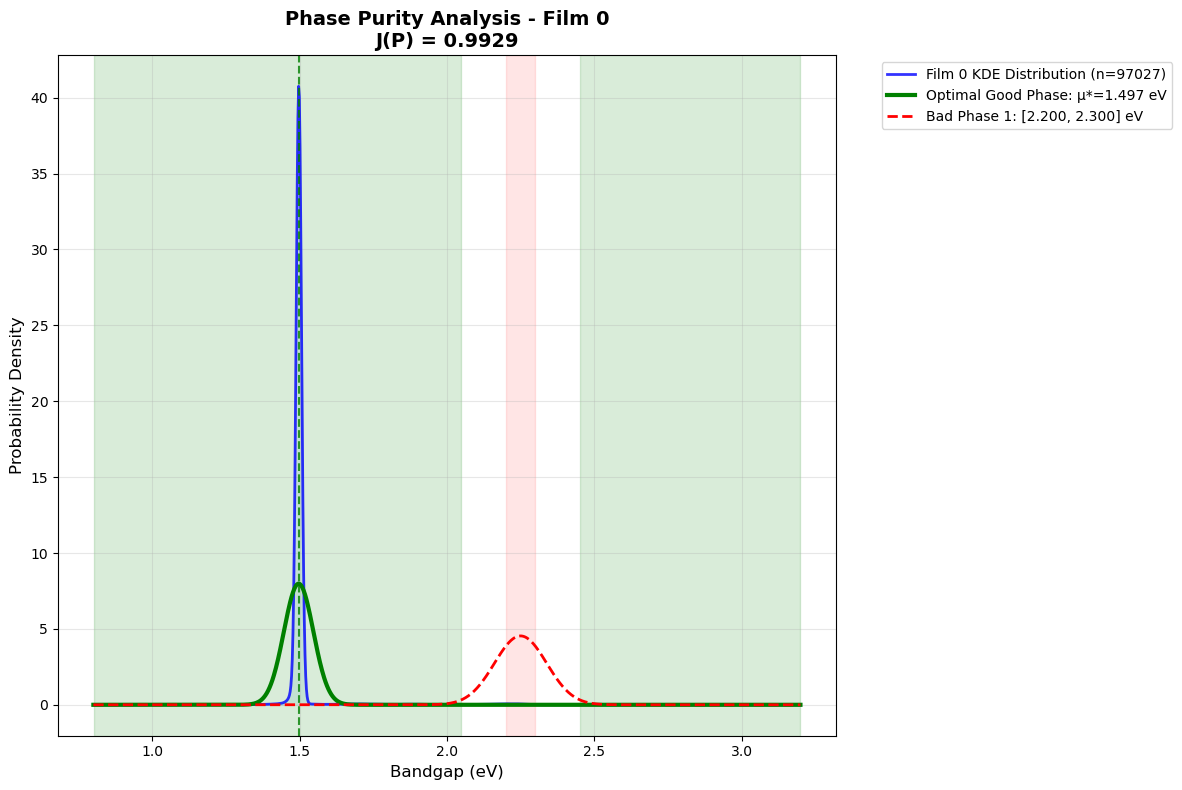

Phase purity score: 0.9929
Optimal μ*: 1.497 eV
Bandgaps found: 97027

Processing Film 1...


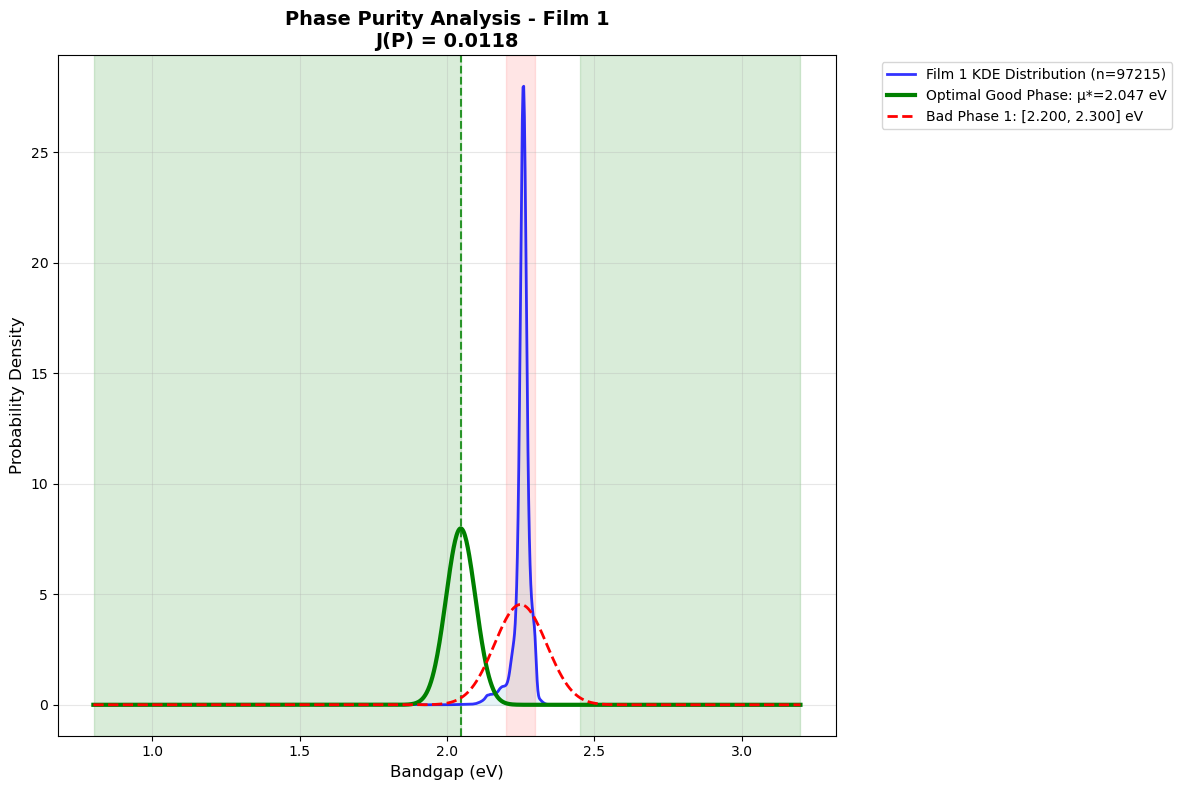

Phase purity score: 0.0118
Optimal μ*: 2.047 eV
Bandgaps found: 97215

Processing Film 2...


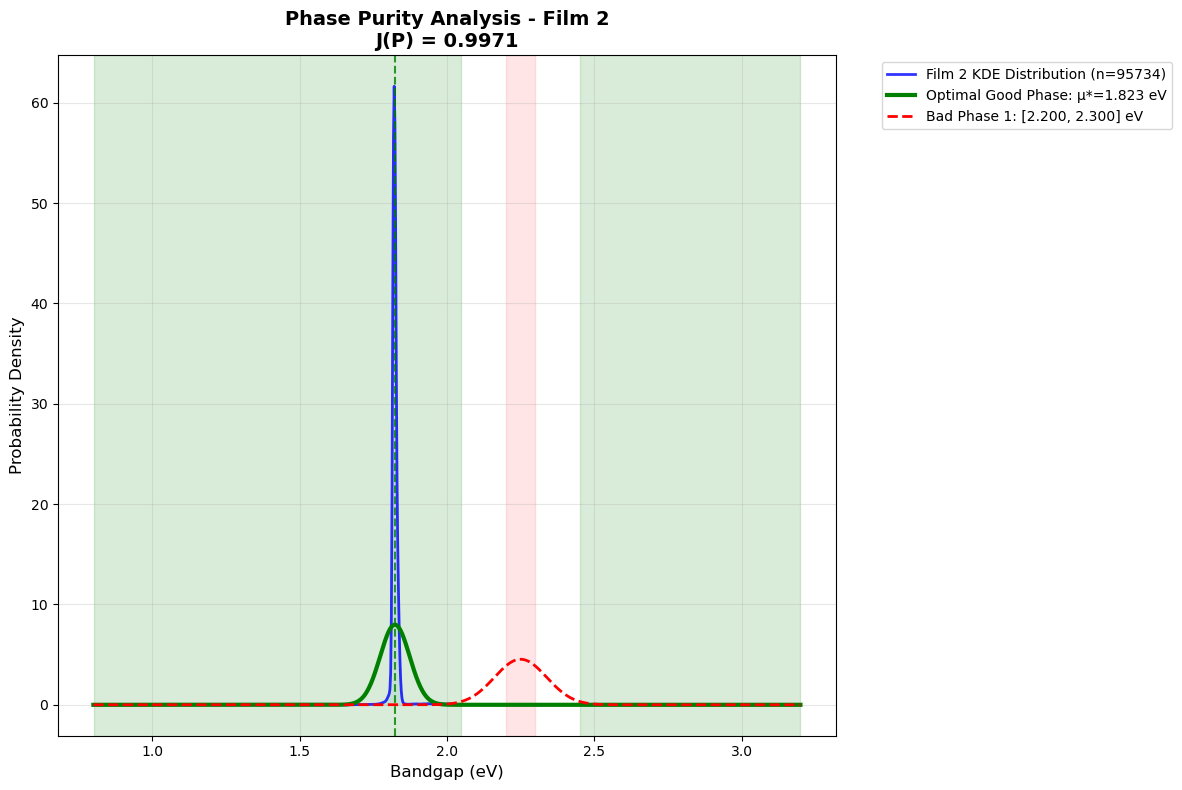

Phase purity score: 0.9971
Optimal μ*: 1.823 eV
Bandgaps found: 95734

Processing Film 3...


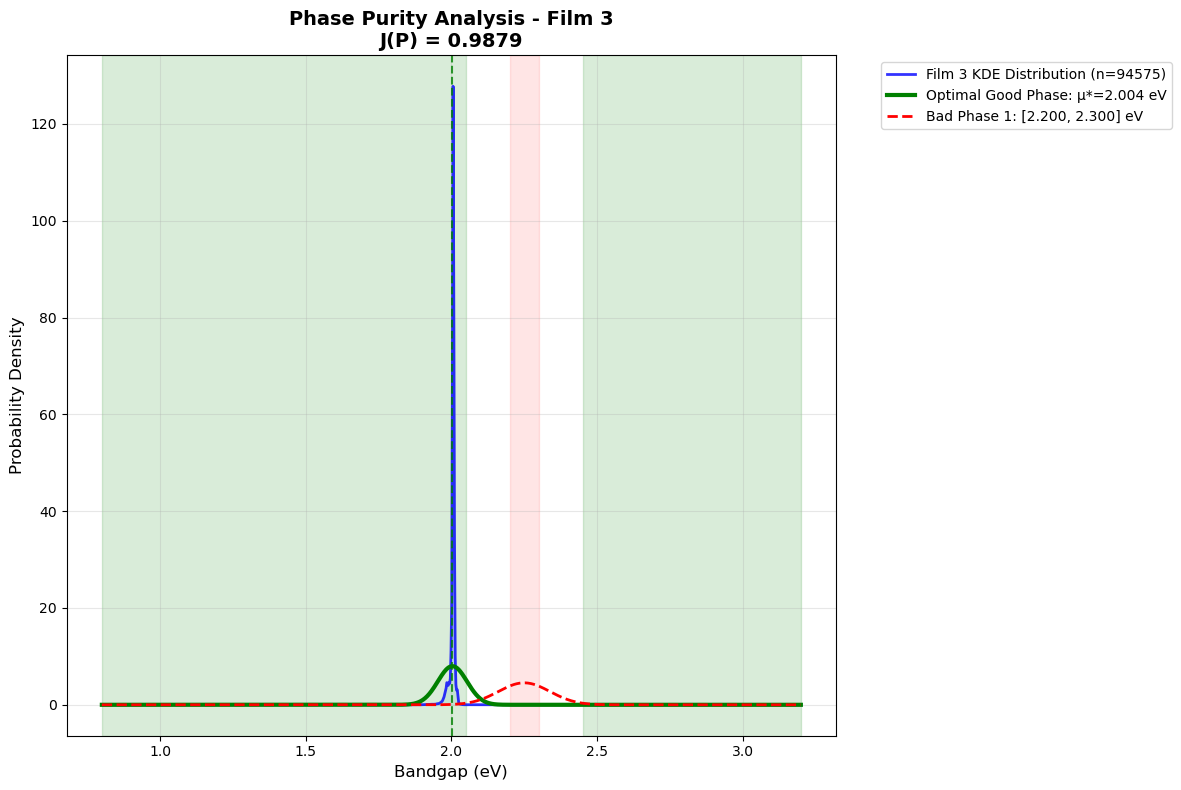

Phase purity score: 0.9879
Optimal μ*: 2.004 eV
Bandgaps found: 94575

Processing Film 4...


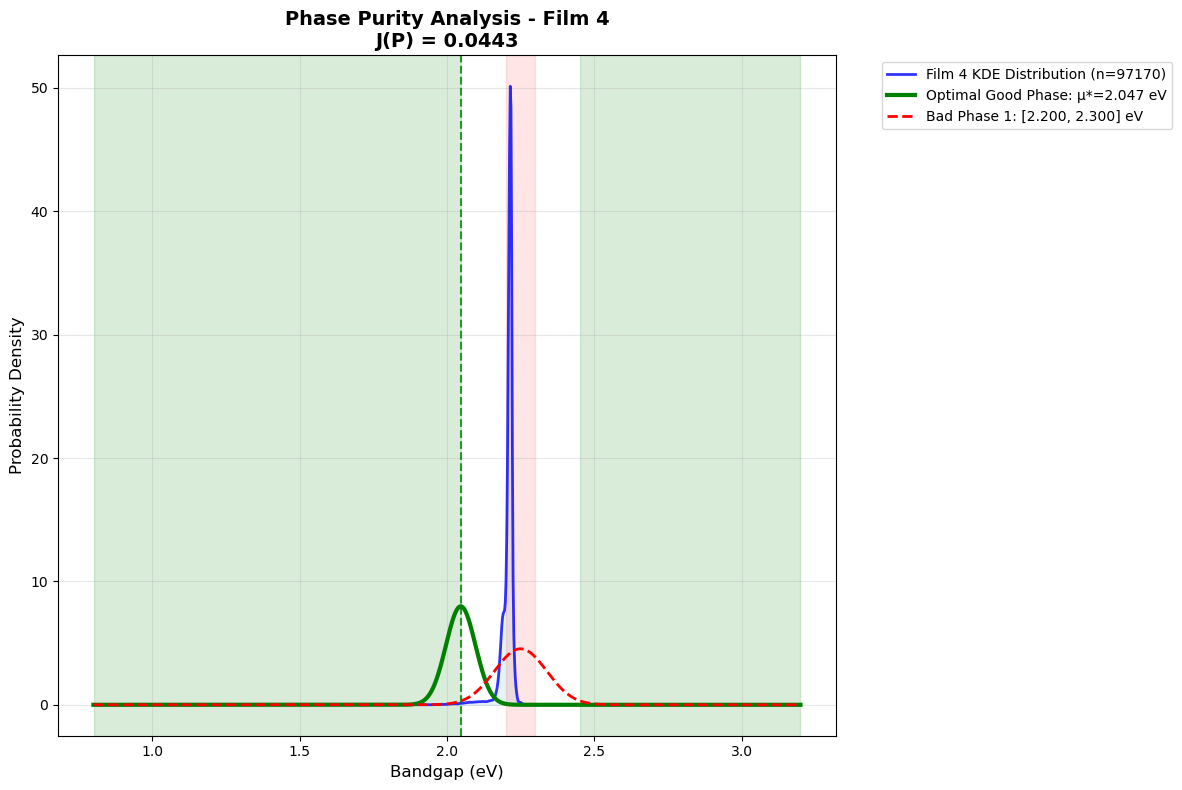

Phase purity score: 0.0443
Optimal μ*: 2.047 eV
Bandgaps found: 97170
   film_id  phase_purity
0        0      0.992874
1        1      0.011832
2        2      0.997107
3        3      0.987931
4        4      0.044324


In [75]:
bad_phase_ranges=[(2.20, 2.30)] 

# Analysis parameters
analysis_params = {
    'sigma_good': 0.05,      # Width of good phase (narrow)
    'sigma_bad': 0.08,       # Width of bad phases
    'penalty_lambda': 1.0,   # Penalty strength for bad phase overlap
    'exclusion_delta': 0.15,  # Minimum separation from bad phases (eV)
    'ev_min': 1.0,          # Minimum energy for bandgap analysis
    'ev_max': 3.0,           # Maximum energy for bandgap analysis
}

# Initialize results list
phase_purity_list = []

# Process each film (following your format)
for film_idx in range(0, 5):
    print(f"\nProcessing Film {film_idx}...")

    try:
        df = pd.read_csv(f"{datapath}film_{film_idx}_bandgaps.csv", header=None)
        # skip first row
        data = df.iloc[1:]
        # convert to numeric
        data = data.apply(pd.to_numeric, errors='coerce')
        # convert each row → list of valid bandgaps
        bandgaps = [
            [bg for bg in row if bg > 0 and np.isfinite(bg)]
            for row in data.values
        ]
        phase_purity_results = calculate_phase_purity_score(
            bandgaps,
            bad_phase_ranges=bad_phase_ranges,
            **analysis_params,
            return_debug=True,
            save_figures=True,
            
        )

        if 'error' in phase_purity_results:
            print(f"Error: {phase_purity_results['error']}")
            phase_purity_score = np.nan
        else:
            phase_purity_score = phase_purity_results['phase_purity_score']
            print(f"Phase purity score: {phase_purity_score:.4f}")
            print(f"Optimal μ*: {phase_purity_results['optimal_mu']:.3f} eV")
            print(f"Bandgaps found: {phase_purity_results['n_bandgaps']}")
        phase_purity_list.append(phase_purity_score)
        
    except Exception as e:
        print(f"Exception: {str(e)}")
        phase_purity_list.append(np.nan)

# Analysis parameters
analysis_params = {
    'sigma_good': 0.05,      # Width of good phase (narrow)
    'sigma_bad': 0.08,       # Width of bad phases
    'penalty_lambda': 1.0,   # Penalty strength for bad phase overlap
    'exclusion_delta': 0.15,  # Minimum separation from bad phases (eV)
    'ev_min': 1.0,          # Minimum energy for bandgap analysis
    'ev_max': 3.0,           # Maximum energy for bandgap analysis
}

# Create individual results DataFrame
df_phase_purity = pd.DataFrame({
    "film_id": range(len(phase_purity_list)),
    "phase_purity": phase_purity_list
})

# Display individual results
print(df_phase_purity)

# Save individual results
df_phase_purity.to_csv(f"{savepath}/phase_purity_individual_bandgap.csv", index=False)